# Lab 8

By Niksh Hiremath (U20240158)


## 1. Code


### Importing libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

### Loading dataset


In [2]:
df = pd.read_csv("data.csv")
df.shape

(2000, 6)

In [3]:
df.head()

,Cancer stage,Clump thickness,No of week,Clump thickness_new,No of week_new,True cancer stage
0,1.0,10.510076,6.166544,10.269649,11.999203,1
1,1.0,11.739776,7.024066,10.494287,6.495638,1
2,1.0,7.857070,5.909366,8.516879,7.102108,1
3,1.0,10.817929,5.920890,8.979736,9.196251,1
4,1.0,10.302407,6.984937,9.553005,7.120283,1


In [5]:
df.isna().sum()

Cancer stage           1800
Clump thickness        1800
No of week             1800
Clump thickness_new       0
No of week_new            0
True cancer stage         0
dtype: int64

### Plotting the dataset


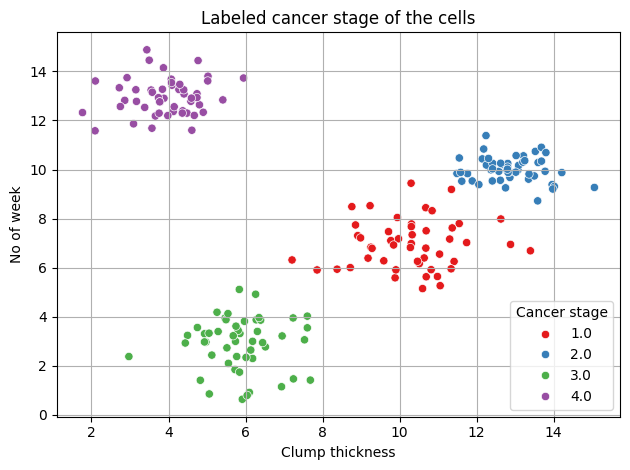

In [ ]:
plt.figure()

sns.scatterplot(
    df,
    x="Clump thickness",
    y="No of week",
    hue="Cancer stage",
    palette="Set1",
)

plt.title("Labeled cancer stage of the cells")
plt.tight_layout()
plt.grid()
plt.show()

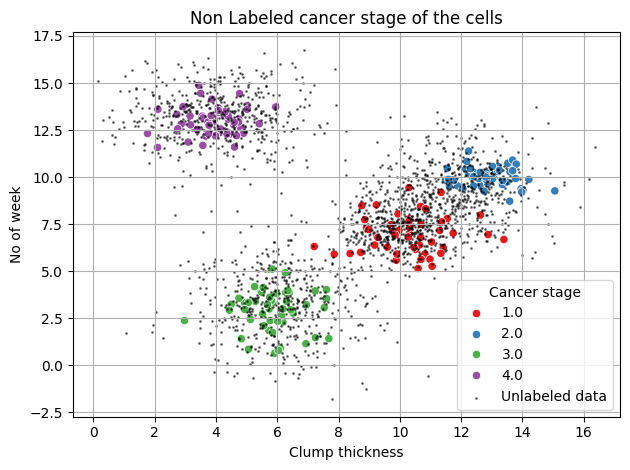

In [21]:
plt.figure()

sns.scatterplot(
    df,
    x="Clump thickness",
    y="No of week",
    hue="Cancer stage",
    palette="Set1",
)
plt.scatter(
    df["Clump thickness_new"],
    df["No of week_new"],
    color="black",
    label="Unlabeled data",
    alpha=0.5,
    s=1,
)

plt.title(f"Non Labeled cancer stage of the cells")
plt.tight_layout()
plt.legend(title="Cancer stage")
plt.grid()
plt.show()

### Preprocessing


In [36]:
df_labeled = df[df["Cancer stage"].notna()]
X_labeled = df_labeled[["Clump thickness", "No of week"]]
y_labeled = df_labeled["Cancer stage"]

In [37]:
X = df[["Clump thickness_new", "No of week_new"]]
y = df["True cancer stage"]

### Model development and evaluation


In [24]:
knn = KNeighborsClassifier()
stm = SelfTrainingClassifier(knn)

In [38]:
stm.fit(X_labeled.values, y_labeled)

c:\Users\niksh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\semi_supervised\_self_training.py:244: UserWarning: y contains no unlabeled samples
  warnings.warn("y contains no unlabeled samples", UserWarning)


,"estimator estimator: estimator objectAn estimator object implementing `fit` and `predict_proba`.Invoking the `fit` method will fit a clone of the passed estimator,which will be stored in the `estimator_` attribute... versionadded:: 1.6 `estimator` was added to replace `base_estimator`.",KNeighborsClassifier()
,"threshold threshold: float, default=0.75The decision threshold for use with `criterion='threshold'`.Should be in [0, 1). When using the `'threshold'` criterion, a:ref:`well calibrated classifier ` should be used.",0.75
,"criterion criterion: {'threshold', 'k_best'}, default='threshold'The selection criterion used to select which labels to add to thetraining set. If `'threshold'`, pseudo-labels with predictionprobabilities above `threshold` are added to the dataset. If `'k_best'`,the `k_best` pseudo-labels with highest prediction probabilities areadded to the dataset. When using the 'threshold' criterion, a:ref:`well calibrated classifier ` should be used.",'threshold'
,"k_best k_best: int, default=10The amount of samples to add in each iteration. Only used when`criterion='k_best'`.",10
,"max_iter max_iter: int or None, default=10Maximum number of iterations allowed. Should be greater than or equalto 0. If it is `None`, the classifier will continue to predict labelsuntil no new pseudo-labels are added, or all unlabeled samples havebeen labeled.",10
,"verbose verbose: bool, default=FalseEnable verbose output.",False
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2


In [39]:
y_pred = stm.predict(X.values)

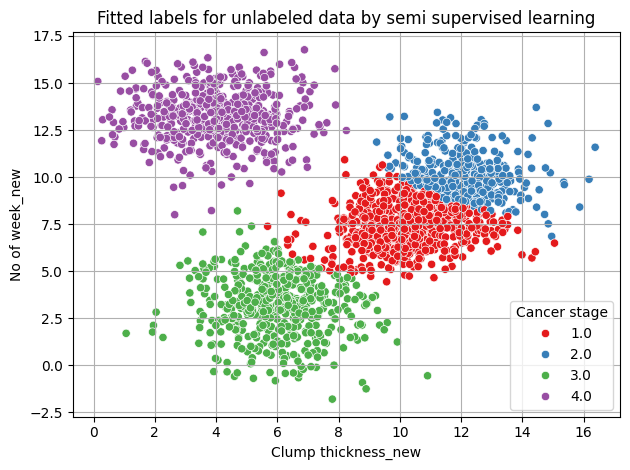

In [44]:
plt.figure()

sns.scatterplot(
    X,
    x="Clump thickness_new",
    y="No of week_new",
    hue=y_pred,
    palette="Set1",
)

plt.title("Fitted labels for unlabeled data by semi supervised learning")
plt.tight_layout()
plt.legend(title="Cancer stage")
plt.grid()
plt.show()

In [48]:
acc = accuracy_score(y, y_pred)
report = classification_report(y, y_pred)

print("Accuracy:", acc)
print("Classification Report:\n", report)

Accuracy: 0.8905
Classification Report:
               precision    recall  f1-score   support

           1       0.71      0.98      0.82       500
           2       0.96      0.65      0.77       500
           3       1.00      0.94      0.97       500
           4       0.99      1.00      1.00       500

    accuracy                           0.89      2000
   macro avg       0.92      0.89      0.89      2000
weighted avg       0.92      0.89      0.89      2000



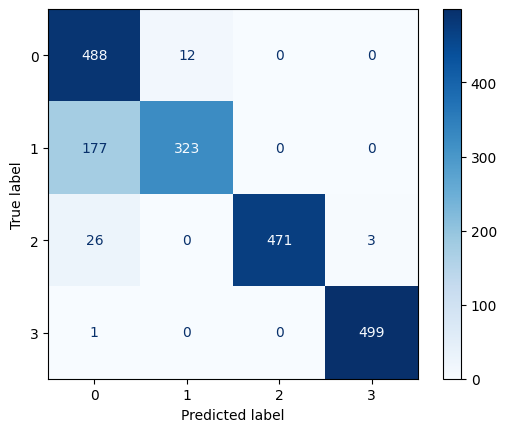

In [ ]:
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## 2. Report


### Q1: Provide three applications of Semi-supervised learning.

**Ans:** 

- Video Recommendation

- Customer Interest Prediction

- Search Engines

---


### Q2: What are the three assumptions of Semi-supervised learning?

**Ans:** 

- **Continuity Assumption:** It is assumed that the points that are closer to each other are more likely to have the same output label.

- **Clustering Assumption:** It is assumed that the data can be divided into discrete clusters and points in the same cluster are more likely to share an output label.

- **Manifold Assumption:** It is assumed that the data lie approximately on a manifold of a much lower dimension than the input space. This assumption allows the use of distances and densities which are defined on a manifold.

---


### Q3: What is significance each of using the above three assumptions in Semi-supervised learning?

**Ans:** 

- **Continuity assumption:** Helps propagate labels to nearby unlabeled samples.

- **Clustering assumption:** Decision boundaries are placed between clusters for better classification.

- **Manifold assumption:** Reduces dimensional complexity and improves learning using the structure of data.

---


### Q4: How does the Co-training method differ from the Self-training method of Semi-supervised learning? Which one usually performs better for accuracy and such performance metrics?

**Ans:** 

- **Self-training:** Uses one classifier. Model generates pseudo-labels for unlabeled data and retrains iteratively.

- **Co-training:** Uses two classifiers trained on the same dataset. Each classifier teaches the other using confident pseudo labels.

- Co-training usually performs better because two classifiers provide more reliable pseudo-labels, improving accuracy and performance metrics.

---


### Q5: How to evaluate the performance of a semi-supervised learning method while training?

**Ans:** 

- Using validation set with labeled data.

- Monitoring metrics such as accuracy, precision, recall or F1-score.

- Checking whether model performance improves after each pseudo labeling iteration.

---
